In [85]:
import matplotlib.pyplot as plt
import numpy as np
import pickle
import sys
sys.path.append('../src/')
from probabilistic_model import ProbabilisticModel

In [86]:
def load_data(model, state):
    '''Method for loading descriptors for the provided model and state.'''
    acsf = np.load(f'../data/descriptors/neigh_16/{model}_{state}_acsf.npy')
    stein = np.load(f'../data/descriptors/neigh_16/{model}_{state}_stein.npy')
    X = np.hstack((acsf, stein))
    return X

In [87]:
def visualize_features(desc, model, hda_desc, lda_desc):
    '''
        Method for visualizing distribution of a state's features
        along the features chosen by the classification model for
        comparison to HDA and LDA distributions.
    '''
    plt.rcParams['font.family'] = 'Helvetica Neue'
    plt.rcParams['font.size'] = 11
    plt.rcParams['axes.linewidth'] = 1.1
    fig, axs = plt.subplots(1,5,figsize=(12.0,3.5))
    for feat_idx, feat in enumerate(model.chosen_features):
        candidate = desc[:,feat]
        hda = hda_desc[:,feat]
        lda = lda_desc[:,feat]
        axs[feat_idx].hist(candidate, bins=30, density=True, color='gray', alpha=0.5, label='Trial')
        axs[feat_idx].hist(hda, bins=30, density=True, color='blue', alpha=0.5, label='HDA')
        axs[feat_idx].hist(lda, bins=30, density=True, color='red', alpha=0.5, label='LDA')
        axs[feat_idx].spines[['top', 'right']].set_visible(False)
        axs[feat_idx].set_xlabel(f'Desc #{feat_idx + 1}')
        # axs[feat_idx].set_ylabel('')
        axs[feat_idx].set_yticks([])
    plt.tight_layout()
    plt.show()

In [88]:
# Load model for evaluation.
MODEL = 'scan'
m1 = pickle.load(open(f'../data/models/model_{MODEL}_size_16_feat_5_include_0.999.pkl', 'rb'))
m2 = pickle.load(open(f'../data/models/model_{MODEL}_size_16_feat_120_include_0.999.pkl', 'rb'))

In [89]:
# Make prediction on HDA (baseline).
hda_desc = load_data(MODEL, 'hda')
y1 = m1.predict(hda_desc)
y2 = m2.predict(hda_desc)
accuracy = len(np.argwhere(y1 == 0).reshape(-1)) / y1.shape[0]
print(f'5-feature Outlier Accuracy: {accuracy:.3f}')
accuracy = len(np.argwhere(y2 == 0).reshape(-1)) / y2.shape[0]
print(f'120-feature Outlier Accuracy: {accuracy:.3f}')

5-feature Outlier Accuracy: 0.988
120-feature Outlier Accuracy: 0.991


In [90]:
# Make prediction on LDA (baseline).
lda_desc = load_data(MODEL, 'lda')
y1 = m1.predict(lda_desc)
y2 = m2.predict(lda_desc)
accuracy = len(np.argwhere(y1 == 1).reshape(-1)) / y1.shape[0]
print(f'5-feature Outlier Accuracy: {accuracy:.3f}')
accuracy = len(np.argwhere(y2 == 1).reshape(-1)) / y2.shape[0]
print(f'120-feature Outlier Accuracy: {accuracy:.3f}')

5-feature Outlier Accuracy: 0.945
120-feature Outlier Accuracy: 0.947


5-feature Outlier Accuracy: 0.003
120-feature Outlier Accuracy: 1.000


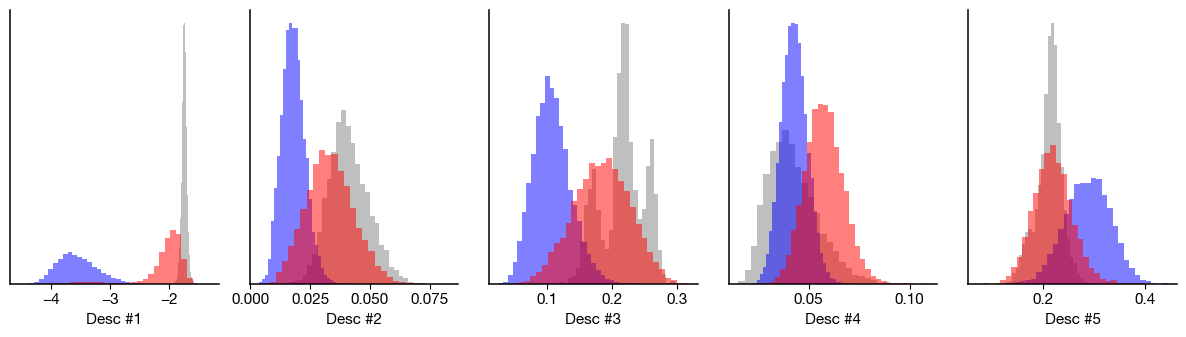

In [91]:
# Make prediction on hexagonal ice (baseline).
desc = load_data(MODEL, 'ice')
y1 = m1.predict(desc)
y2 = m2.predict(desc)
accuracy = len(np.argwhere(y1 == -1).reshape(-1)) / y1.shape[0]
print(f'5-feature Outlier Accuracy: {accuracy:.3f}')
accuracy = len(np.argwhere(y2 == -1).reshape(-1)) / y2.shape[0]
print(f'120-feature Outlier Accuracy: {accuracy:.3f}')

# Visualize distributions along features.
visualize_features(desc, m1, hda_desc, lda_desc)

5-feature Outlier Accuracy: 0.562
120-feature Outlier Accuracy: 0.998


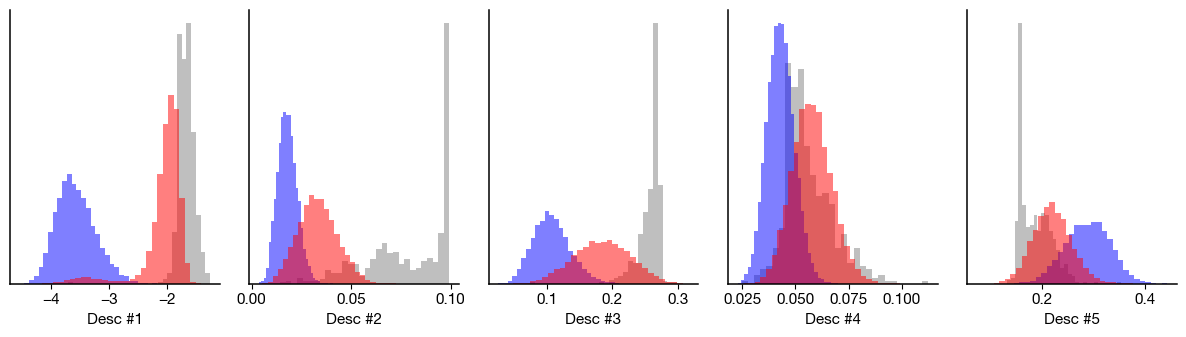

In [92]:
# Make prediction on ice01c.
desc = load_data(MODEL, 'ice01c')
y1 = m1.predict(desc)
y2 = m2.predict(desc)
accuracy = len(np.argwhere(y1 == -1).reshape(-1)) / y1.shape[0]
print(f'5-feature Outlier Accuracy: {accuracy:.3f}')
accuracy = len(np.argwhere(y2 == -1).reshape(-1)) / y2.shape[0]
print(f'120-feature Outlier Accuracy: {accuracy:.3f}')

# Visualize distributions along features.
visualize_features(desc, m1, hda_desc, lda_desc)

5-feature Outlier Accuracy: 0.037
120-feature Outlier Accuracy: 0.142


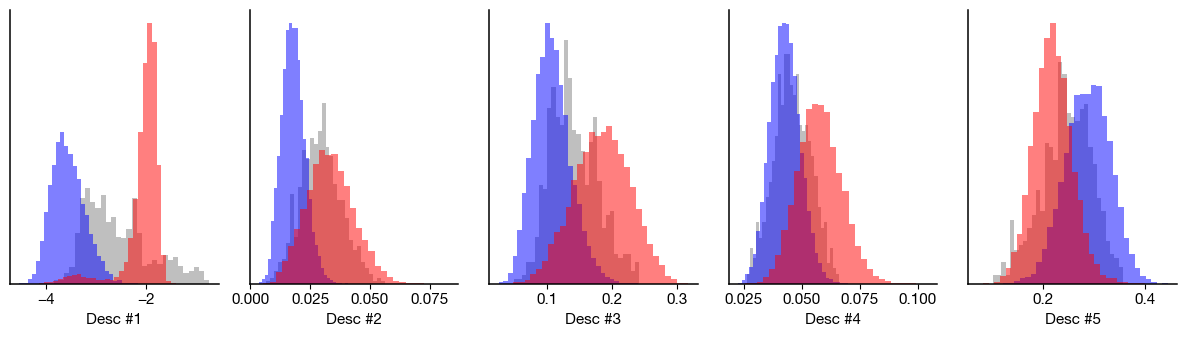

In [93]:
# Make prediction on ice02.
desc = load_data(MODEL, 'ice02')
y1 = m1.predict(desc)
y2 = m2.predict(desc)
accuracy = len(np.argwhere(y1 == -1).reshape(-1)) / y1.shape[0]
print(f'5-feature Outlier Accuracy: {accuracy:.3f}')
accuracy = len(np.argwhere(y2 == -1).reshape(-1)) / y2.shape[0]
print(f'120-feature Outlier Accuracy: {accuracy:.3f}')

# Visualize distributions along features.
visualize_features(desc, m1, hda_desc, lda_desc)

5-feature Outlier Accuracy: 0.000
120-feature Outlier Accuracy: 0.956


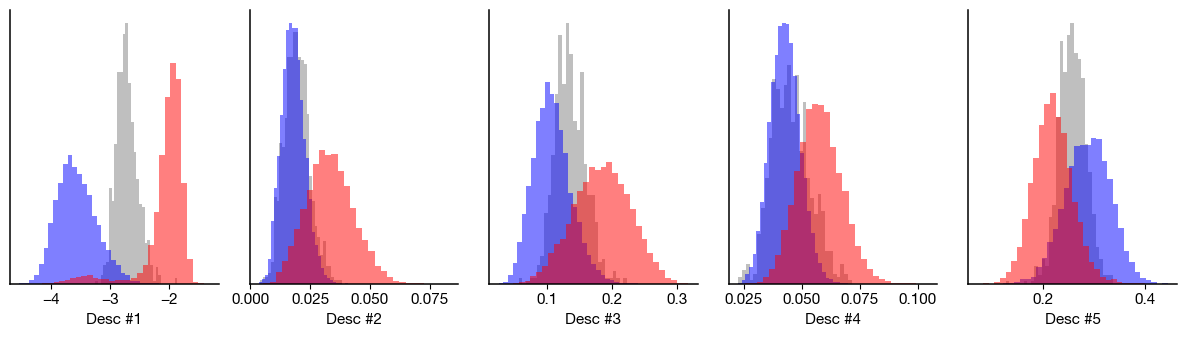

In [94]:
# Make prediction on ice03.
desc = load_data(MODEL, 'ice03')
y1 = m1.predict(desc)
y2 = m2.predict(desc)
accuracy = len(np.argwhere(y1 == -1).reshape(-1)) / y1.shape[0]
print(f'5-feature Outlier Accuracy: {accuracy:.3f}')
accuracy = len(np.argwhere(y2 == -1).reshape(-1)) / y2.shape[0]
print(f'120-feature Outlier Accuracy: {accuracy:.3f}')

# Visualize distributions along features.
visualize_features(desc, m1, hda_desc, lda_desc)

5-feature Outlier Accuracy: 0.076
120-feature Outlier Accuracy: 0.184


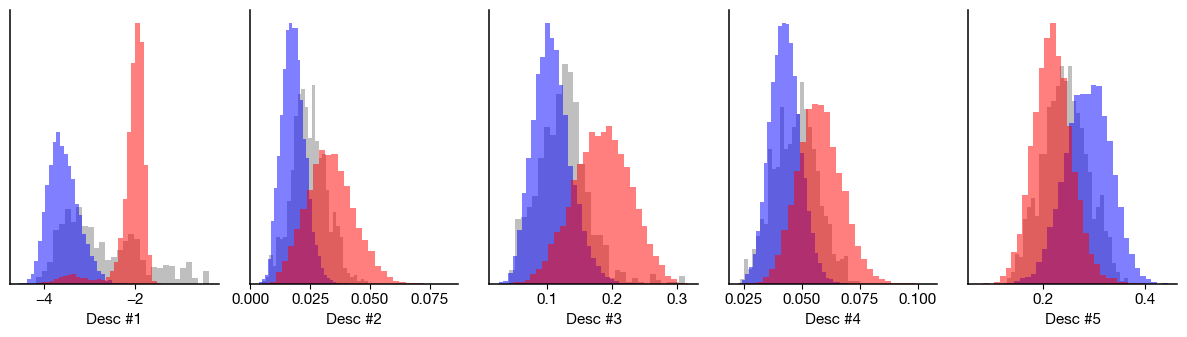

In [95]:
# Make prediction on ice04.
desc = load_data(MODEL, 'ice04')
y1 = m1.predict(desc)
y2 = m2.predict(desc)
accuracy = len(np.argwhere(y1 == -1).reshape(-1)) / y1.shape[0]
print(f'5-feature Outlier Accuracy: {accuracy:.3f}')
accuracy = len(np.argwhere(y2 == -1).reshape(-1)) / y2.shape[0]
print(f'120-feature Outlier Accuracy: {accuracy:.3f}')

# Visualize distributions along features.
visualize_features(desc, m1, hda_desc, lda_desc)

5-feature Outlier Accuracy: 0.067
120-feature Outlier Accuracy: 0.481


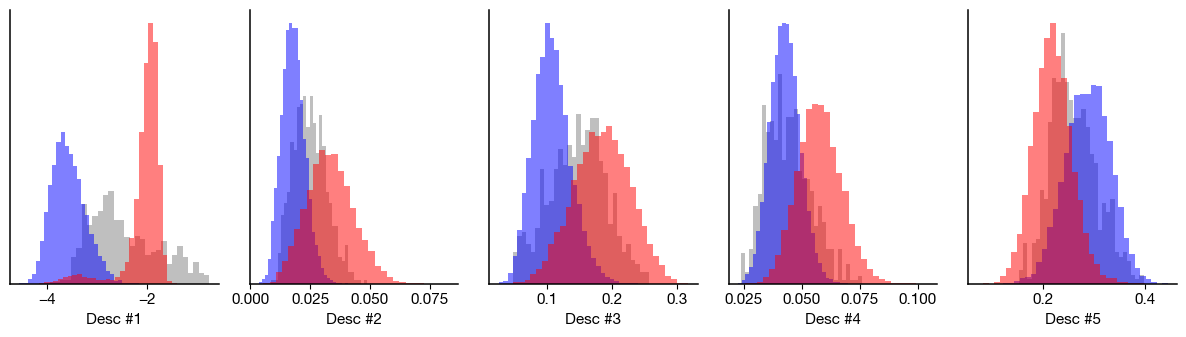

In [96]:
# Make prediction on ice05.
desc = load_data(MODEL, 'ice05')
y1 = m1.predict(desc)
y2 = m2.predict(desc)
accuracy = len(np.argwhere(y1 == -1).reshape(-1)) / y1.shape[0]
print(f'5-feature Outlier Accuracy: {accuracy:.3f}')
accuracy = len(np.argwhere(y2 == -1).reshape(-1)) / y2.shape[0]
print(f'120-feature Outlier Accuracy: {accuracy:.3f}')

# Visualize distributions along features.
visualize_features(desc, m1, hda_desc, lda_desc)

5-feature Outlier Accuracy: 0.010
120-feature Outlier Accuracy: 0.700


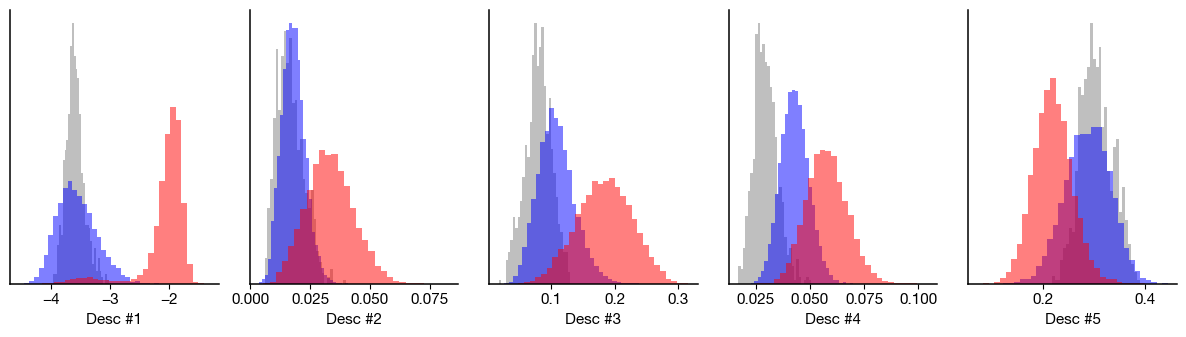

In [97]:
# Make prediction on ice06.
desc = load_data(MODEL, 'ice06')
y1 = m1.predict(desc)
y2 = m2.predict(desc)
accuracy = len(np.argwhere(y1 == -1).reshape(-1)) / y1.shape[0]
print(f'5-feature Outlier Accuracy: {accuracy:.3f}')
accuracy = len(np.argwhere(y2 == -1).reshape(-1)) / y2.shape[0]
print(f'120-feature Outlier Accuracy: {accuracy:.3f}')

# Visualize distributions along features.
visualize_features(desc, m1, hda_desc, lda_desc)

5-feature Outlier Accuracy: 0.907
120-feature Outlier Accuracy: 1.000


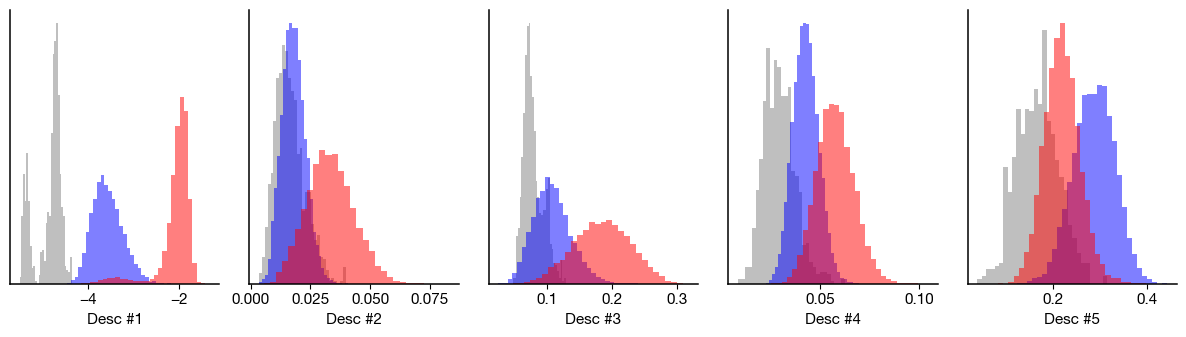

In [98]:
# Make prediction on ice07.
desc = load_data(MODEL, 'ice07')
y1 = m1.predict(desc)
y2 = m2.predict(desc)
accuracy = len(np.argwhere(y1 == -1).reshape(-1)) / y1.shape[0]
print(f'5-feature Outlier Accuracy: {accuracy:.3f}')
accuracy = len(np.argwhere(y2 == -1).reshape(-1)) / y2.shape[0]
print(f'120-feature Outlier Accuracy: {accuracy:.3f}')

# Visualize distributions along features.
visualize_features(desc, m1, hda_desc, lda_desc)

5-feature Outlier Accuracy: 0.851
120-feature Outlier Accuracy: 1.000


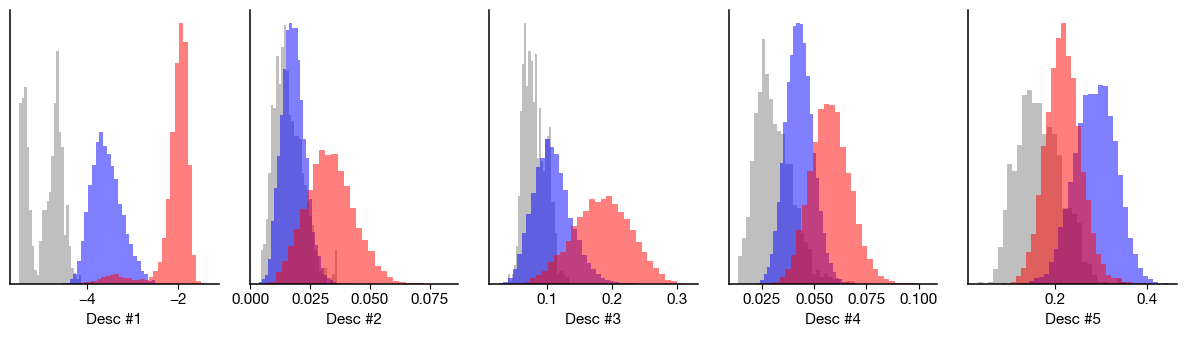

In [99]:
# Make prediction on ice08.
desc = load_data(MODEL, 'ice08')
y1 = m1.predict(desc)
y2 = m2.predict(desc)
accuracy = len(np.argwhere(y1 == -1).reshape(-1)) / y1.shape[0]
print(f'5-feature Outlier Accuracy: {accuracy:.3f}')
accuracy = len(np.argwhere(y2 == -1).reshape(-1)) / y2.shape[0]
print(f'120-feature Outlier Accuracy: {accuracy:.3f}')

# Visualize distributions along features.
visualize_features(desc, m1, hda_desc, lda_desc)

5-feature Outlier Accuracy: 0.000
120-feature Outlier Accuracy: 1.000


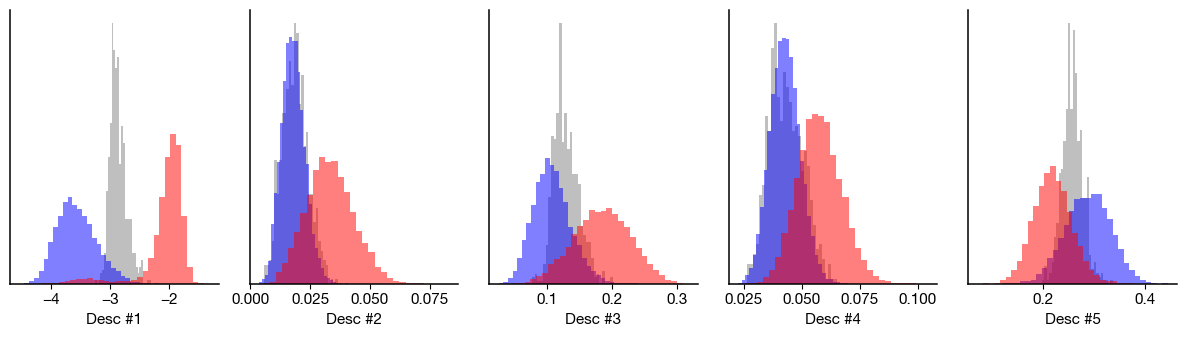

In [100]:
# Make prediction on ice09.
desc = load_data(MODEL, 'ice09')
y1 = m1.predict(desc)
y2 = m2.predict(desc)
accuracy = len(np.argwhere(y1 == -1).reshape(-1)) / y1.shape[0]
print(f'5-feature Outlier Accuracy: {accuracy:.3f}')
accuracy = len(np.argwhere(y2 == -1).reshape(-1)) / y2.shape[0]
print(f'120-feature Outlier Accuracy: {accuracy:.3f}')

visualize_features(desc, m1, hda_desc, lda_desc)

5-feature Outlier Accuracy: 0.008
120-feature Outlier Accuracy: 1.000


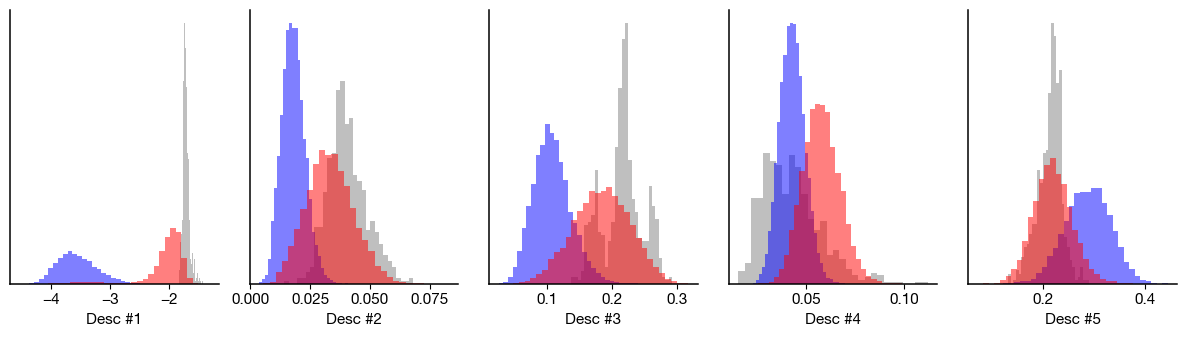

In [101]:
# Make prediction on ice11.
desc = load_data(MODEL, 'ice11')
y1 = m1.predict(desc)
y2 = m2.predict(desc)
accuracy = len(np.argwhere(y1 == -1).reshape(-1)) / y1.shape[0]
print(f'5-feature Outlier Accuracy: {accuracy:.3f}')
accuracy = len(np.argwhere(y2 == -1).reshape(-1)) / y2.shape[0]
print(f'120-feature Outlier Accuracy: {accuracy:.3f}')

# Visualize distributions along features.
visualize_features(desc, m1, hda_desc, lda_desc)

5-feature Outlier Accuracy: 0.083
120-feature Outlier Accuracy: 0.998


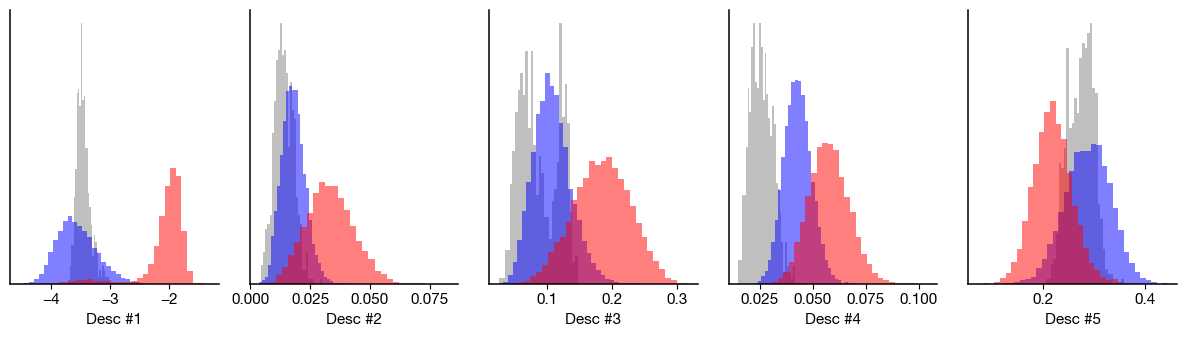

In [102]:
# Make prediction on ice12.
desc = load_data(MODEL, 'ice12')
y1 = m1.predict(desc)
y2 = m2.predict(desc)
accuracy = len(np.argwhere(y1 == -1).reshape(-1)) / y1.shape[0]
print(f'5-feature Outlier Accuracy: {accuracy:.3f}')
accuracy = len(np.argwhere(y2 == -1).reshape(-1)) / y2.shape[0]
print(f'120-feature Outlier Accuracy: {accuracy:.3f}')

# Visualize distributions along features.
visualize_features(desc, m1, hda_desc, lda_desc)

5-feature Outlier Accuracy: 0.008
120-feature Outlier Accuracy: 0.220


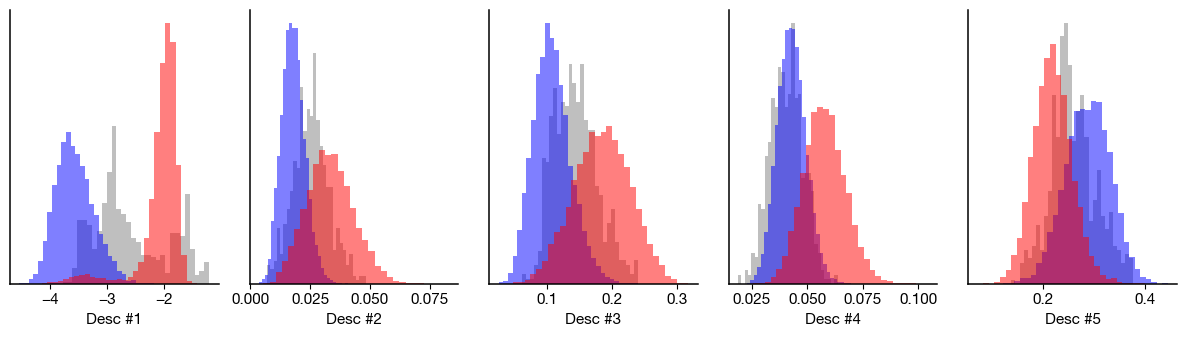

In [103]:
# Make prediction on ice13.
desc = load_data(MODEL, 'ice13')
y1 = m1.predict(desc)
y2 = m2.predict(desc)
accuracy = len(np.argwhere(y1 == -1).reshape(-1)) / y1.shape[0]
print(f'5-feature Outlier Accuracy: {accuracy:.3f}')
accuracy = len(np.argwhere(y2 == -1).reshape(-1)) / y2.shape[0]
print(f'120-feature Outlier Accuracy: {accuracy:.3f}')

# Visualize distributions along features.
visualize_features(desc, m1, hda_desc, lda_desc)

5-feature Outlier Accuracy: 0.075
120-feature Outlier Accuracy: 1.000


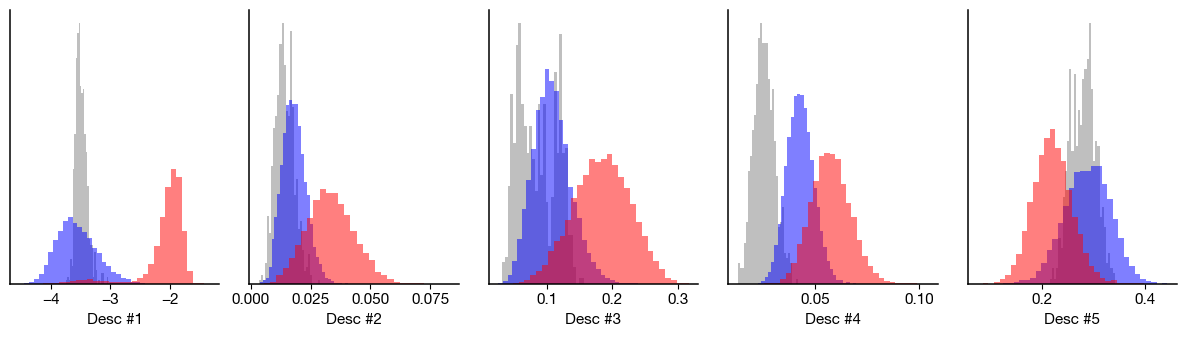

In [104]:
# Make prediction on ice14.
desc = load_data(MODEL, 'ice14')
y1 = m1.predict(desc)
y2 = m2.predict(desc)
accuracy = len(np.argwhere(y1 == -1).reshape(-1)) / y1.shape[0]
print(f'5-feature Outlier Accuracy: {accuracy:.3f}')
accuracy = len(np.argwhere(y2 == -1).reshape(-1)) / y2.shape[0]
print(f'120-feature Outlier Accuracy: {accuracy:.3f}')

# Visualize distributions along features.
visualize_features(desc, m1, hda_desc, lda_desc)

5-feature Outlier Accuracy: 0.023
120-feature Outlier Accuracy: 0.945


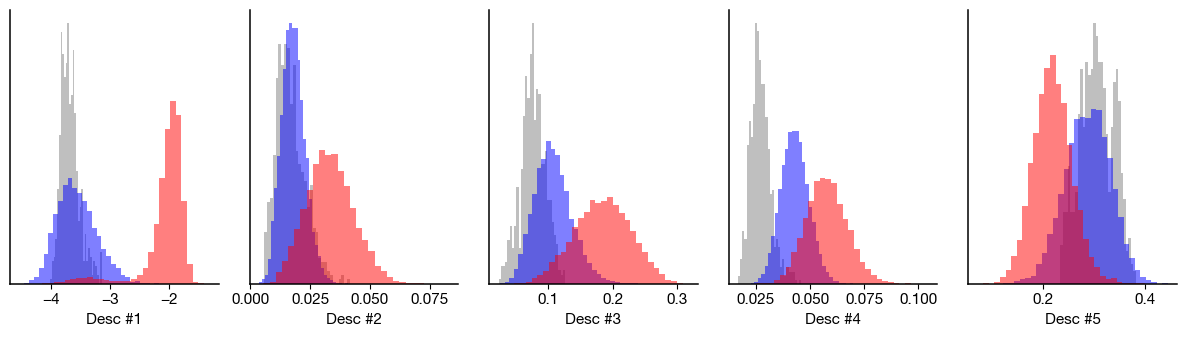

In [105]:
# Make prediction on ice15.
desc = load_data(MODEL, 'ice15')
y1 = m1.predict(desc)
y2 = m2.predict(desc)
accuracy = len(np.argwhere(y1 == -1).reshape(-1)) / y1.shape[0]
print(f'5-feature Outlier Accuracy: {accuracy:.3f}')
accuracy = len(np.argwhere(y2 == -1).reshape(-1)) / y2.shape[0]
print(f'120-feature Outlier Accuracy: {accuracy:.3f}')

# Visualize distributions along features.
visualize_features(desc, m1, hda_desc, lda_desc)